## 1. Setup

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os, shutil, random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Extract dataset

In [2]:
import zipfile

zip_name = "catVsdog.zip"
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/raw_data')

for root, dirs, filenames in os.walk('/content/raw_data'):
    print(root, "->", len(filenames), "files", dirs)

/content/raw_data -> 0 files ['training_set', 'test_set']
/content/raw_data/training_set -> 0 files ['training_set']
/content/raw_data/training_set/training_set -> 0 files ['dogs', 'cats']
/content/raw_data/training_set/training_set/dogs -> 4006 files []
/content/raw_data/training_set/training_set/cats -> 4001 files []
/content/raw_data/test_set -> 0 files ['test_set']
/content/raw_data/test_set/test_set -> 0 files ['dogs', 'cats']
/content/raw_data/test_set/test_set/dogs -> 1013 files []
/content/raw_data/test_set/test_set/cats -> 1012 files []


## 3. Create validation split

In [3]:
import shutil, random

random.seed(42)

base = '/content/data'
src_train = '/content/raw_data/training_set/training_set'
src_test = '/content/raw_data/test_set/test_set'

val_split = 0.15

for split in ['train', 'val', 'test']:
    for cls in ['cats', 'dogs']:
        os.makedirs(f'{base}/{split}/{cls}', exist_ok=True)

for cls in ['cats', 'dogs']:
    files = os.listdir(f'{src_train}/{cls}')
    files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(files)

    n_val = int(len(files) * val_split)
    val_files = files[:n_val]
    train_files = files[n_val:]

    for f in train_files:
        shutil.copy(f'{src_train}/{cls}/{f}', f'{base}/train/{cls}/{f}')
    for f in val_files:
        shutil.copy(f'{src_train}/{cls}/{f}', f'{base}/val/{cls}/{f}')

    test_files = [f for f in os.listdir(f'{src_test}/{cls}') if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in test_files:
        shutil.copy(f'{src_test}/{cls}/{f}', f'{base}/test/{cls}/{f}')

    print(f'{cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test')

cats: 3400 train, 600 val, 1011 test
dogs: 3405 train, 600 val, 1012 test


## 4. EDA — class balance

In [4]:
for split in ['train', 'val', 'test']:
    cats = len(os.listdir(f'/content/data/{split}/cats'))
    dogs = len(os.listdir(f'/content/data/{split}/dogs'))
    print(f'{split}: cats={cats}, dogs={dogs}, total={cats+dogs}')

train: cats=3400, dogs=3405, total=6805
val: cats=600, dogs=600, total=1200
test: cats=1011, dogs=1012, total=2023


## 5. EDA — image size distribution

Width  - min: 59 max: 500 mean: 404.74333333333334
Height - min: 55 max: 500 mean: 355.3566666666667


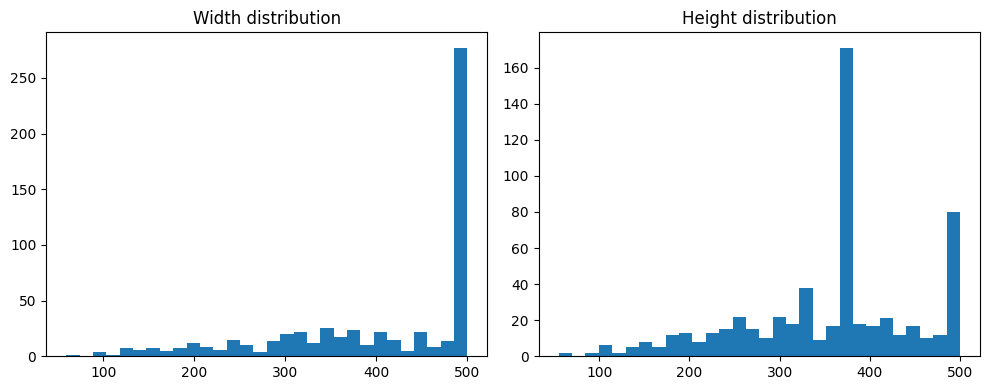

In [5]:
def sample_image_sizes(folder, n=300):
    files = os.listdir(folder)
    sample = random.sample(files, min(n, len(files)))
    sizes = []
    for f in sample:
        with Image.open(f'{folder}/{f}') as img:
            sizes.append(img.size)
    return sizes

cat_sizes = sample_image_sizes('/content/data/train/cats')
dog_sizes = sample_image_sizes('/content/data/train/dogs')
all_sizes = cat_sizes + dog_sizes

widths = [s[0] for s in all_sizes]
heights = [s[1] for s in all_sizes]

print("Width  - min:", min(widths), "max:", max(widths), "mean:", np.mean(widths))
print("Height - min:", min(heights), "max:", max(heights), "mean:", np.mean(heights))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title('Width distribution')
plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title('Height distribution')
plt.tight_layout()
plt.show()

## 5b. EDA — image size distribution (full scan)

Total images scanned: 6805
Width  - min: 57 max: 500 mean: 404.2
Height - min: 45 max: 500 mean: 359.9


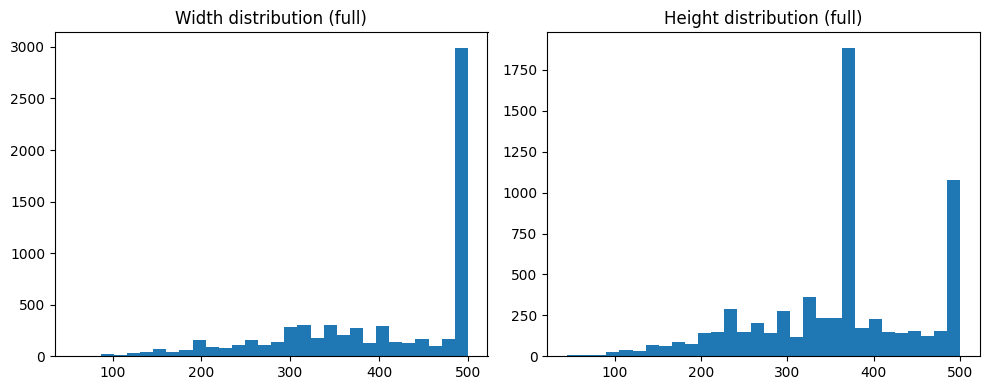

In [6]:
def all_image_sizes(folder):
    sizes = []
    for f in os.listdir(folder):
        with Image.open(f'{folder}/{f}') as img:
            sizes.append(img.size)
    return sizes

cat_sizes = all_image_sizes('/content/data/train/cats')
dog_sizes = all_image_sizes('/content/data/train/dogs')
all_sizes = cat_sizes + dog_sizes

widths = [s[0] for s in all_sizes]
heights = [s[1] for s in all_sizes]

print("Total images scanned:", len(all_sizes))
print("Width  - min:", min(widths), "max:", max(widths), "mean:", round(np.mean(widths), 1))
print("Height - min:", min(heights), "max:", max(heights), "mean:", round(np.mean(heights), 1))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title('Width distribution (full)')
plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title('Height distribution (full)')
plt.tight_layout()
plt.show()

## 6. EDA — sample image grid

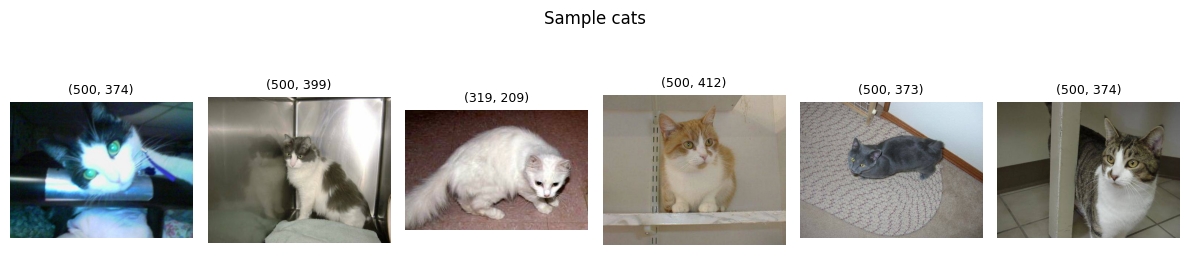

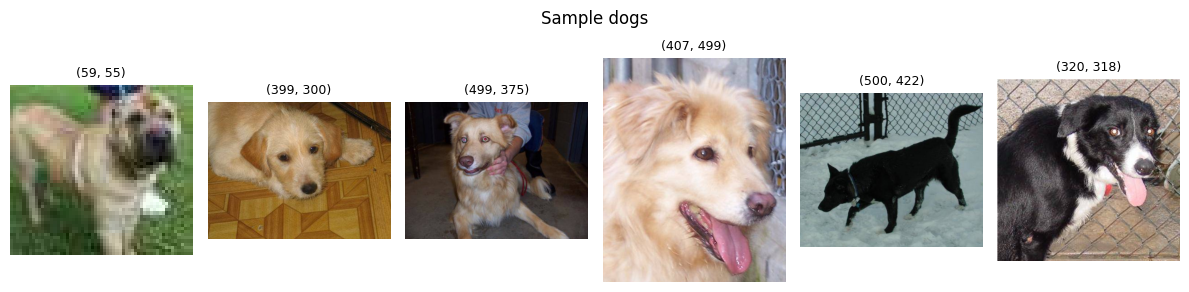

In [7]:
def show_sample_grid(folder, title, n=6):
    files = random.sample(os.listdir(folder), n)
    plt.figure(figsize=(12, 3))
    for i, f in enumerate(files):
        img = Image.open(f'{folder}/{f}')
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f'{img.size}', fontsize=9)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample_grid('/content/data/train/cats', 'Sample cats')
show_sample_grid('/content/data/train/dogs', 'Sample dogs')

## 7. EDA — pixel intensity distribution

Cat pixels - min: 0 max: 255 mean: 114.4
Dog pixels - min: 0 max: 255 mean: 117.3


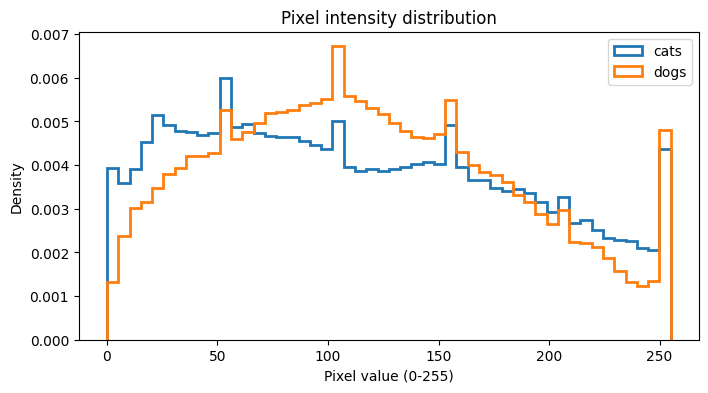

In [8]:
def sample_pixel_values(folder, n=100):
    files = random.sample(os.listdir(folder), n)
    pixel_values = []
    for f in files:
        img = Image.open(f'{folder}/{f}').convert('RGB').resize((100,100))
        arr = np.array(img)
        pixel_values.append(arr.flatten())
    return np.concatenate(pixel_values)

cat_pixels = sample_pixel_values('/content/data/train/cats')
dog_pixels = sample_pixel_values('/content/data/train/dogs')

print("Cat pixels - min:", cat_pixels.min(), "max:", cat_pixels.max(), "mean:", round(cat_pixels.mean(),1))
print("Dog pixels - min:", dog_pixels.min(), "max:", dog_pixels.max(), "mean:", round(dog_pixels.mean(),1))

plt.figure(figsize=(8,4))
plt.hist(cat_pixels, bins=50, histtype='step', linewidth=2, label='cats', density=True)
plt.hist(dog_pixels, bins=50, histtype='step', linewidth=2, label='dogs', density=True)
plt.legend()
plt.title('Pixel intensity distribution')
plt.xlabel('Pixel value (0-255)')
plt.ylabel('Density')
plt.show()

## 8. Data augmentation visualization

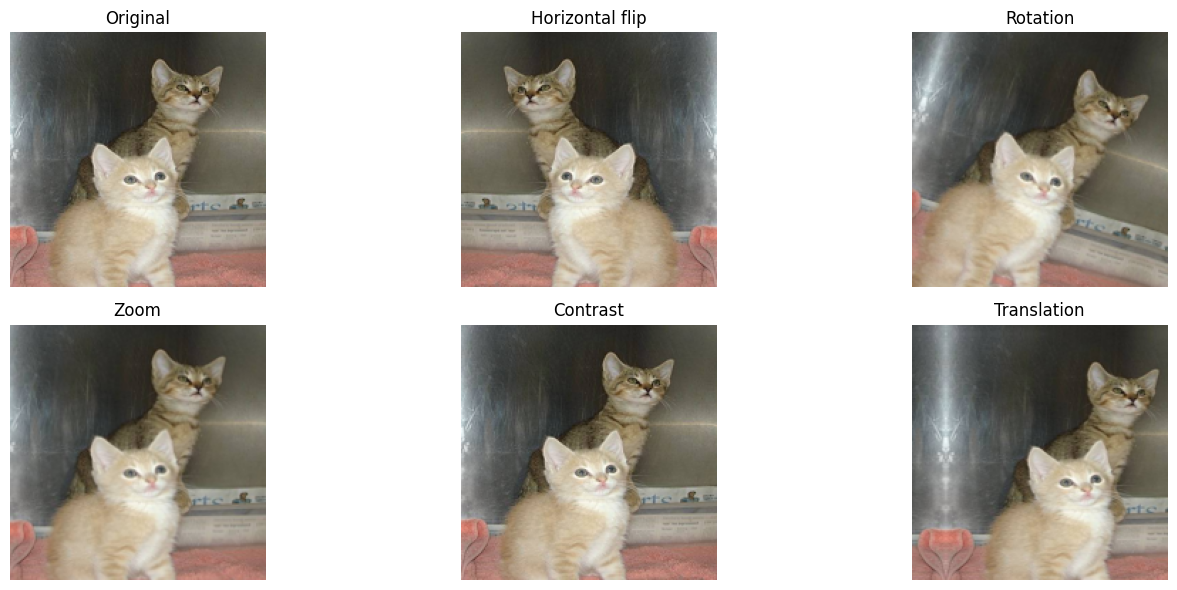

In [9]:
sample_path = f"/content/data/train/cats/{os.listdir('/content/data/train/cats')[0]}"
sample_img = Image.open(sample_path).convert('RGB').resize((180,180))
sample_arr = np.expand_dims(np.array(sample_img), 0).astype("float32")

augmentations = {
    "Original": None,
    "Horizontal flip": layers.RandomFlip("horizontal"),
    "Rotation": layers.RandomRotation(0.15),
    "Zoom": layers.RandomZoom(0.15),
    "Contrast": layers.RandomContrast(0.15),
    "Translation": layers.RandomTranslation(0.15, 0.15),
}

plt.figure(figsize=(15, 6))
for i, (name, layer) in enumerate(augmentations.items()):
    if layer is None:
        img_to_show = sample_arr[0]
    else:
        img_to_show = layer(sample_arr, training=True)[0].numpy()
    img_to_show = np.clip(img_to_show, 0, 255).astype("uint8")
    plt.subplot(2, 3, i+1)
    plt.imshow(img_to_show)
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 9. Data loading pipeline

In [10]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

def make_dataset(split, color_mode='rgb', shuffle=True):
    return keras.utils.image_dataset_from_directory(
        f'/content/data/{split}',
        labels='inferred',
        label_mode='binary',
        color_mode=color_mode,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42
    )

train_ds = make_dataset('train')
val_ds = make_dataset('val')
test_ds = make_dataset('test', shuffle=False)

print("Class names:", train_ds.class_names)

# performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 6805 files belonging to 2 classes.
Found 1200 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
Class names: ['cats', 'dogs']


## 10. Baseline CNN model

In [11]:
def build_model(padding='same', stride=1, kernel_size=3, input_shape=(150,150,3), use_augmentation=False):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    if use_augmentation:
        x = data_augmentation(x)

    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, kernel_size, strides=stride, padding=padding, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, kernel_size, strides=stride, padding=padding, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, kernel_size, strides=stride, padding=padding, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_model()
baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        41,473 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,721 (526.25 KB)

 Trainable params: 134,721 (526.25 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Results tracking setup

In [14]:
results = []

def log_result(name, history, model):
    results[:] = [r for r in results if r['experiment'] != name]
    best_epoch = np.argmin(history.history['val_loss'])
    results.append({
        'experiment': name,
        'val_accuracy': history.history['val_accuracy'][best_epoch],
        'val_loss': history.history['val_loss'][best_epoch],
        'epochs_trained': len(history.history['val_loss']),
        'best_epoch': best_epoch + 1,
        'total_params': model.count_params()
    })
    print(f"Logged: {name}")

def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Train accuracy')
    plt.plot(epochs_range, val_acc, label='Val accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{title} - Accuracy')

    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Train loss')
    plt.plot(epochs_range, val_loss, label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{title} - Loss')
    plt.tight_layout()
    plt.show()

import pandas as pd
print("Results tracker ready.")

Results tracker ready.


## 12. Train baseline model

Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.5794 - loss: 0.6697 - val_accuracy: 0.6608 - val_loss: 0.6110
Epoch 2/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7057 - loss: 0.5720 - val_accuracy: 0.7108 - val_loss: 0.5639
Epoch 3/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7509 - loss: 0.5157 - val_accuracy: 0.7425 - val_loss: 0.5243
Epoch 4/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7888 - loss: 0.4579 - val_accuracy: 0.7525 - val_loss: 0.5108
Epoch 5/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8106 - loss: 0.4109 - val_accuracy: 0.7525 - val_loss: 0.5469
Epoch 6/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8444 - loss: 0.3533 - val_accuracy: 0.7400 - val_loss: 0.6003
Epoch 7/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8751 - loss: 0.2936 - val_accuracy: 0.7042 - val_loss: 0.7205


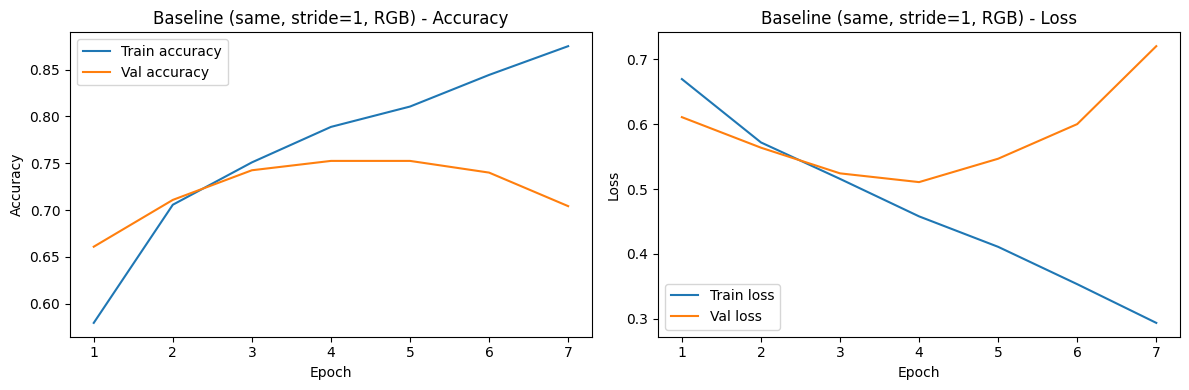

Logged: Baseline (same, stride=1, RGB)


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.7525,0.510765,7,4,134721


In [15]:
early_stop_baseline = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

baseline_model = build_model(padding='same', stride=1, kernel_size=3)

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_baseline]
)

plot_history(history_baseline, 'Baseline (same, stride=1, RGB)')
log_result('Baseline (same, stride=1, RGB)', history_baseline, baseline_model)

pd.DataFrame(results)

## 13. Experiment A — padding = valid

Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.5819 - loss: 0.6636 - val_accuracy: 0.6708 - val_loss: 0.5963
Epoch 2/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.7068 - loss: 0.5645 - val_accuracy: 0.7225 - val_loss: 0.5692
Epoch 3/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7593 - loss: 0.5030 - val_accuracy: 0.7550 - val_loss: 0.5104
Epoch 4/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7949 - loss: 0.4508 - val_accuracy: 0.7583 - val_loss: 0.5026
Epoch 5/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8291 - loss: 0.3954 - val_accuracy: 0.7525 - val_loss: 0.5328
Epoch 6/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8578 - loss: 0.3380 - val_accuracy: 0.7417 - val_loss: 0.6109
Epoch 7/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8832 - loss: 0.2757 - val_accuracy: 0.7275 - val_loss: 0.7604


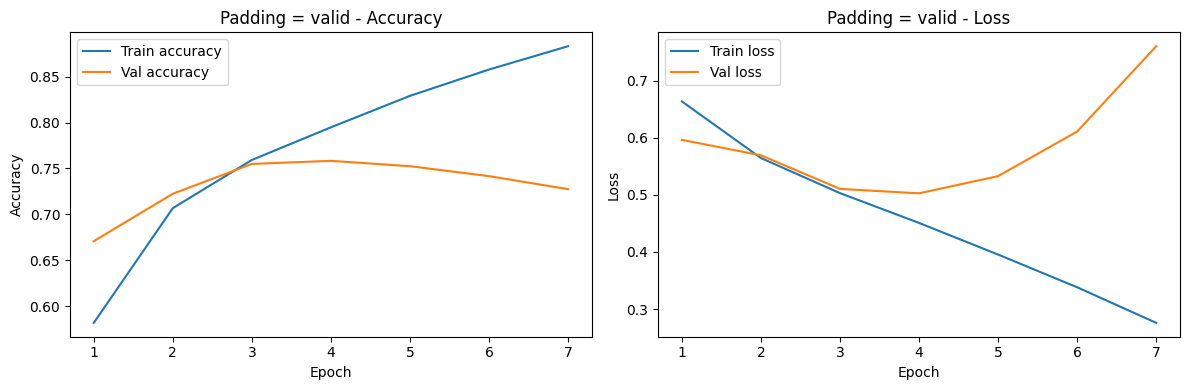

Logged: Padding = valid


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241


In [16]:
early_stop_a = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_padding_valid = build_model(padding='valid', stride=1, kernel_size=3)

history_padding_valid = model_padding_valid.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_a]
)

plot_history(history_padding_valid, 'Padding = valid')
log_result('Padding = valid', history_padding_valid, model_padding_valid)

pd.DataFrame(results)

## 14. Experiment B — stride = 2

Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5653 - loss: 0.6807 - val_accuracy: 0.6550 - val_loss: 0.6316
Epoch 2/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6749 - loss: 0.6052 - val_accuracy: 0.7167 - val_loss: 0.5610
Epoch 3/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7308 - loss: 0.5463 - val_accuracy: 0.7408 - val_loss: 0.5326
Epoch 4/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7672 - loss: 0.4900 - val_accuracy: 0.7533 - val_loss: 0.5090
Epoch 5/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7960 - loss: 0.4417 - val_accuracy: 0.7458 - val_loss: 0.5146
Epoch 6/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8170 - loss: 0.4007 - val_accuracy: 0.7600 - val_loss: 0.5077
Epoch 7/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8458 - loss: 0.3483 - val_accuracy: 0.7400 - val_loss: 0.5526
Epoch 8/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8733 - loss: 0.2987 - val_accuracy: 0

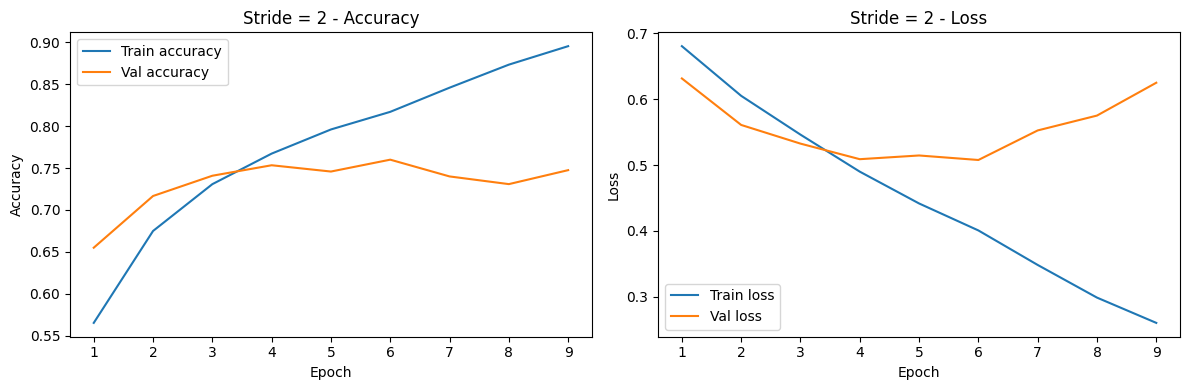

Logged: Stride = 2


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761


In [17]:
early_stop_b = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_stride2 = build_model(padding='same', stride=2, kernel_size=3)

history_stride2 = model_stride2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_b]
)

plot_history(history_stride2, 'Stride = 2')
log_result('Stride = 2', history_stride2, model_stride2)

pd.DataFrame(results)

## 15. Experiment C — greyscale

Found 6805 files belonging to 2 classes.
Found 1200 files belonging to 2 classes.
Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5731 - loss: 0.6779 - val_accuracy: 0.6200 - val_loss: 0.6395
Epoch 2/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.7005 - loss: 0.5806 - val_accuracy: 0.7158 - val_loss: 0.5588
Epoch 3/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7678 - loss: 0.4976 - val_accuracy: 0.7567 - val_loss: 0.5106
Epoch 4/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7987 - loss: 0.4408 - val_accuracy: 0.7725 - val_loss: 0.4981
Epoch 5/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8288 - loss: 0.3927 - val_accuracy: 0.7767 - val_loss: 0.5006
Epoch 6/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8463 - loss: 0.3440 - val_accuracy: 0.7492 - val_loss: 0.5700
Epoch 7/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8691 - loss: 0.3080 - val_accuracy: 0.7333 - val_loss: 0.6428


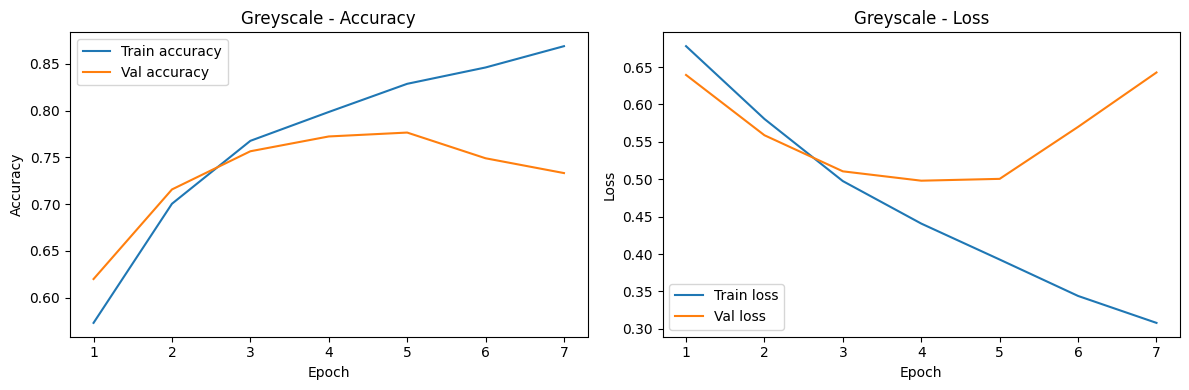

Logged: Greyscale


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761
3,Greyscale,0.772500,0.498112,7,4,134145


In [18]:
train_ds_gray = make_dataset('train', color_mode='grayscale')
val_ds_gray = make_dataset('val', color_mode='grayscale')

train_ds_gray = train_ds_gray.cache().prefetch(buffer_size=AUTOTUNE)
val_ds_gray = val_ds_gray.cache().prefetch(buffer_size=AUTOTUNE)

early_stop_c = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_gray = build_model(padding='same', stride=1, kernel_size=3, input_shape=(150,150,1))

history_gray = model_gray.fit(
    train_ds_gray,
    validation_data=val_ds_gray,
    epochs=25,
    callbacks=[early_stop_c]
)

plot_history(history_gray, 'Greyscale')
log_result('Greyscale', history_gray, model_gray)

pd.DataFrame(results)

## 16. Experiment D — data augmentation

Epoch 1/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5715 - loss: 0.6722 - val_accuracy: 0.6525 - val_loss: 0.6228
Epoch 2/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6625 - loss: 0.6190 - val_accuracy: 0.7008 - val_loss: 0.5749
Epoch 3/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6964 - loss: 0.5858 - val_accuracy: 0.7158 - val_loss: 0.5573
Epoch 4/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6992 - loss: 0.5768 - val_accuracy: 0.7458 - val_loss: 0.5334
Epoch 5/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7183 - loss: 0.5546 - val_accuracy: 0.7383 - val_loss: 0.5219
Epoch 6/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7290 - loss: 0.5347 - val_accuracy: 0.7408 - val_loss: 0.5277
Epoch 7/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7449 - loss: 0.5190 - val_accuracy: 0.7625 - val_loss: 0.4964
Epoch 8/30
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7539 - loss: 0.5060 - val_ac

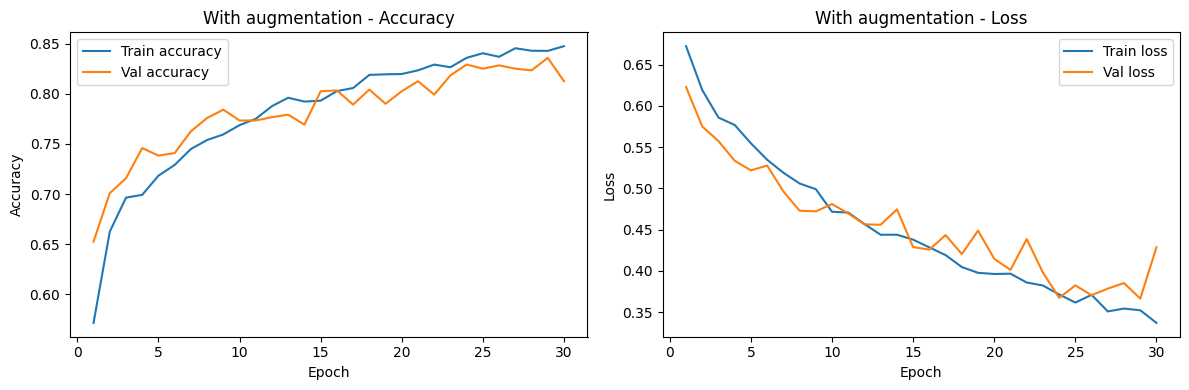

Logged: With augmentation


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761
3,Greyscale,0.772500,0.498112,7,4,134145
4,With augmentation,0.835833,0.366596,30,29,134721


In [19]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

early_stop_d = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_aug = build_model(padding='same', stride=1, kernel_size=3, use_augmentation=True)

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop_d]
)

plot_history(history_aug, 'With augmentation')
log_result('With augmentation', history_aug, model_aug)

pd.DataFrame(results)

Rerun with 50 epoch

Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5542 - loss: 0.6798 - val_accuracy: 0.6342 - val_loss: 0.6542
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6604 - loss: 0.6240 - val_accuracy: 0.6425 - val_loss: 0.6315
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6830 - loss: 0.5987 - val_accuracy: 0.6900 - val_loss: 0.5961
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6980 - loss: 0.5840 - val_accuracy: 0.7067 - val_loss: 0.5690
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7136 - loss: 0.5632 - val_accuracy: 0.7317 - val_loss: 0.5494
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7309 - loss: 0.5397 - val_accuracy: 0.7442 - val_loss: 0.5250
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7420 - loss: 0.5163 - val_accuracy: 0.7375 - val_loss: 0.5352
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7508 - loss: 0.5065 - val_accu

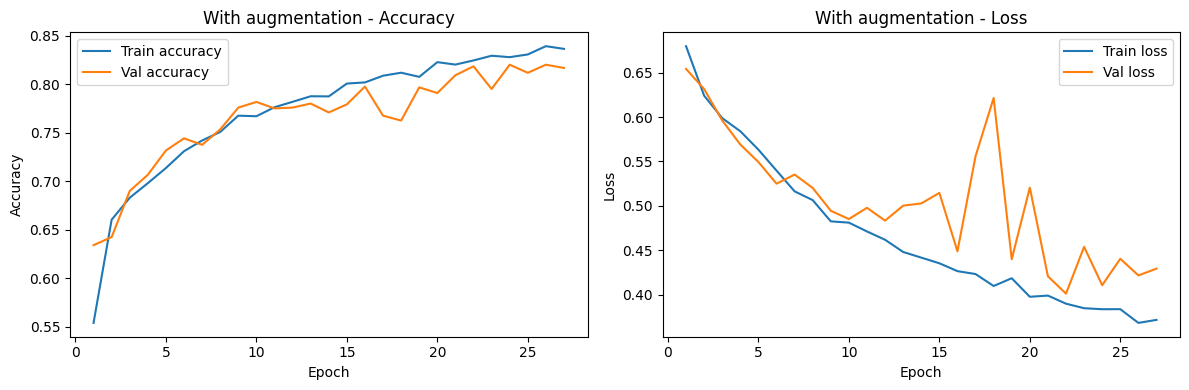

Logged: With augmentation


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761
3,Greyscale,0.772500,0.498112,7,4,134145
4,With augmentation,0.818333,0.401144,27,22,134721


In [20]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

early_stop_d = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_aug = build_model(padding='same', stride=1, kernel_size=3, use_augmentation=True)

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop_d]
)

plot_history(history_aug, 'With augmentation')
log_result('With augmentation', history_aug, model_aug)

pd.DataFrame(results)

## 17. Experiment E — kernel size = 5x5

Epoch 1/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.5569 - loss: 0.6910 - val_accuracy: 0.5625 - val_loss: 0.6801
Epoch 2/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6241 - loss: 0.6456 - val_accuracy: 0.6742 - val_loss: 0.6355
Epoch 3/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.6876 - loss: 0.5932 - val_accuracy: 0.7225 - val_loss: 0.5636
Epoch 4/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7373 - loss: 0.5387 - val_accuracy: 0.7550 - val_loss: 0.5179
Epoch 5/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7652 - loss: 0.4872 - val_accuracy: 0.7483 - val_loss: 0.5316
Epoch 6/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8018 - loss: 0.4349 - val_accuracy: 0.7675 - val_loss: 0.5211
Epoch 7/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.8304 - loss: 0.3822 - val_accuracy: 0.7708 - val_loss: 0.5359


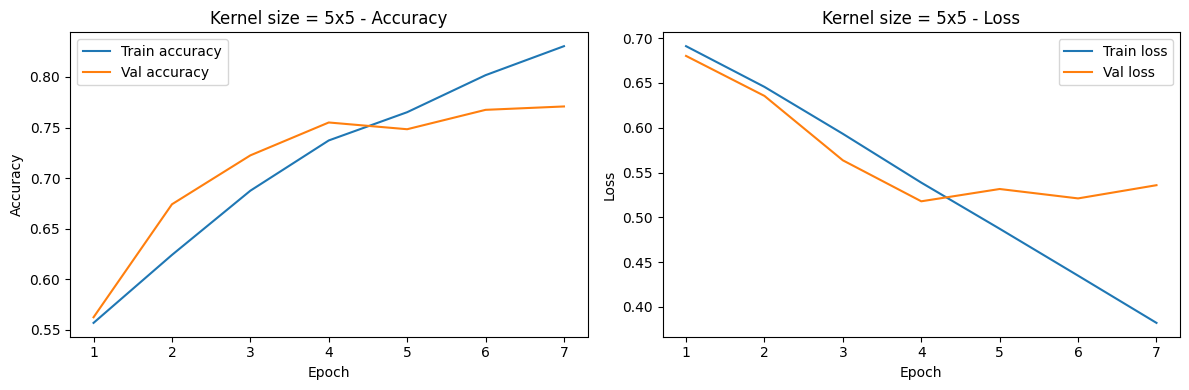

Logged: Kernel size = 5x5


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761
3,Greyscale,0.772500,0.498112,7,4,134145
4,With augmentation,0.818333,0.401144,27,22,134721
5,Kernel size = 5x5,0.755000,0.517878,7,4,300097


In [21]:
early_stop_e = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_kernel5 = build_model(padding='same', stride=1, kernel_size=5)

history_kernel5 = model_kernel5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_e]
)

plot_history(history_kernel5, 'Kernel size = 5x5')
log_result('Kernel size = 5x5', history_kernel5, model_kernel5)

pd.DataFrame(results)

## 18. Experiment F — GlobalAveragePooling head (on winning config)

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5402 - loss: 0.6836 - val_accuracy: 0.5667 - val_loss: 0.6592
Epoch 2/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6034 - loss: 0.6590 - val_accuracy: 0.5983 - val_loss: 0.6420
Epoch 3/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6220 - loss: 0.6448 - val_accuracy: 0.6083 - val_loss: 0.6355
Epoch 4/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.6348 - loss: 0.6353 - val_accuracy: 0.6108 - val_loss: 0.6352
Epoch 5/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6542 - loss: 0.6247 - val_accuracy: 0.6258 - val_loss: 0.6253
Epoch 6/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6575 - loss: 0.6175 - val_accuracy: 0.6433 - val_loss: 0.6190
Epoch 7/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6760 - loss: 0.6070 - val_accuracy: 0.6642 - val_loss: 0.6059
Epoch 8/50
213/213 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.6813 - loss: 0.6014 - val_acc

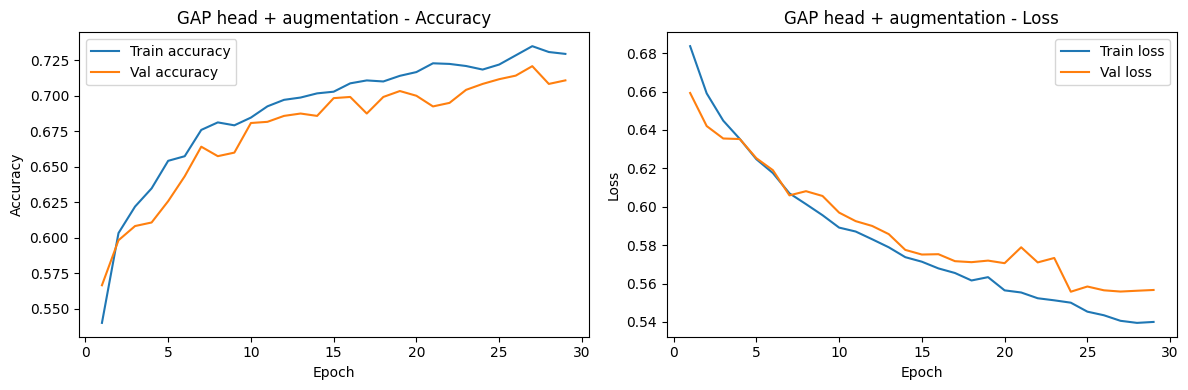

Logged: GAP head + augmentation


,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761
3,Greyscale,0.772500,0.498112,7,4,134145
4,With augmentation,0.818333,0.401144,27,22,134721
5,Kernel size = 5x5,0.755000,0.517878,7,4,300097
6,GAP head + augmentation,0.708333,0.555743,29,24,93377


In [22]:
def build_model_gap(padding='same', stride=1, kernel_size=3, input_shape=(150,150,3), use_augmentation=False):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    if use_augmentation:
        x = data_augmentation(x)

    x = layers.Rescaling(1./255)(x)

    x = layers.Conv2D(32, kernel_size, strides=stride, padding=padding, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, kernel_size, strides=stride, padding=padding, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, kernel_size, strides=stride, padding=padding, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)   # replaces Flatten
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop_f = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_gap = build_model_gap(padding='same', stride=1, kernel_size=3, use_augmentation=True)
model_gap.summary()

history_gap = model_gap.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop_f]
)

plot_history(history_gap, 'GAP head + augmentation')
log_result('GAP head + augmentation', history_gap, model_gap)

pd.DataFrame(results)

## 19. Final evaluation on test set (winning model: augmentation)

64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8344 - loss: 0.3931

Test accuracy: 0.8344
Test loss: 0.3931

              precision    recall  f1-score   support

        cats       0.84      0.82      0.83      1011
        dogs       0.83      0.84      0.84      1012

    accuracy                           0.83      2023
   macro avg       0.83      0.83      0.83      2023
weighted avg       0.83      0.83      0.83      2023



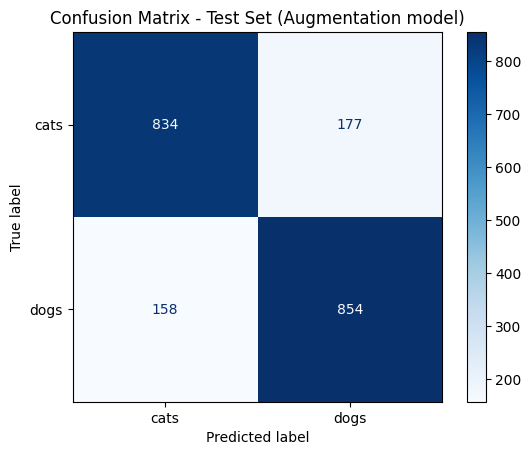

In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0).flatten()
y_pred_proba = model_aug.predict(test_ds).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

test_loss, test_accuracy = model_aug.evaluate(test_ds)
print(f"\nTest accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}\n")

print(classification_report(y_true, y_pred, target_names=['cats', 'dogs']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cats', 'dogs'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set (Augmentation model)')
plt.show()

## 20. Final results summary

In [25]:
pd.DataFrame(results)

,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761
3,Greyscale,0.772500,0.498112,7,4,134145
4,With augmentation,0.818333,0.401144,27,22,134721
5,Kernel size = 5x5,0.755000,0.517878,7,4,300097
6,GAP head + augmentation,0.708333,0.555743,29,24,93377


## 21. Save key plots as image files

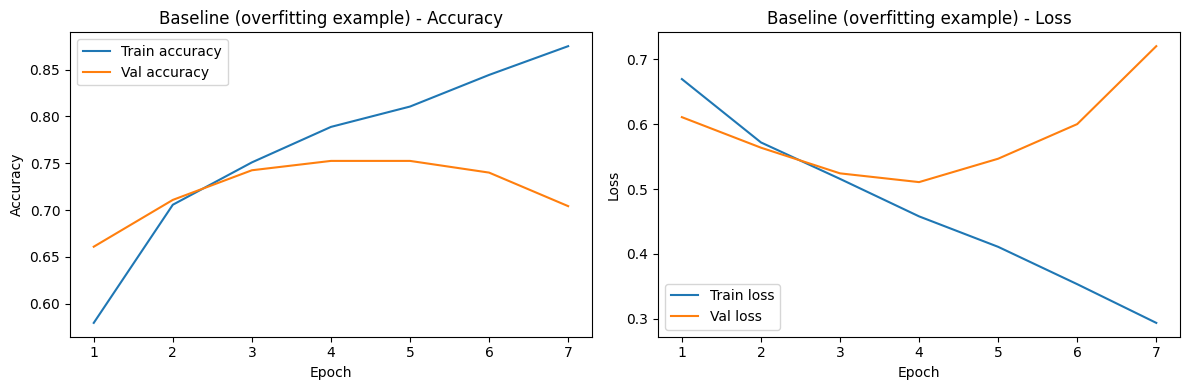

<Figure size 640x480 with 0 Axes>

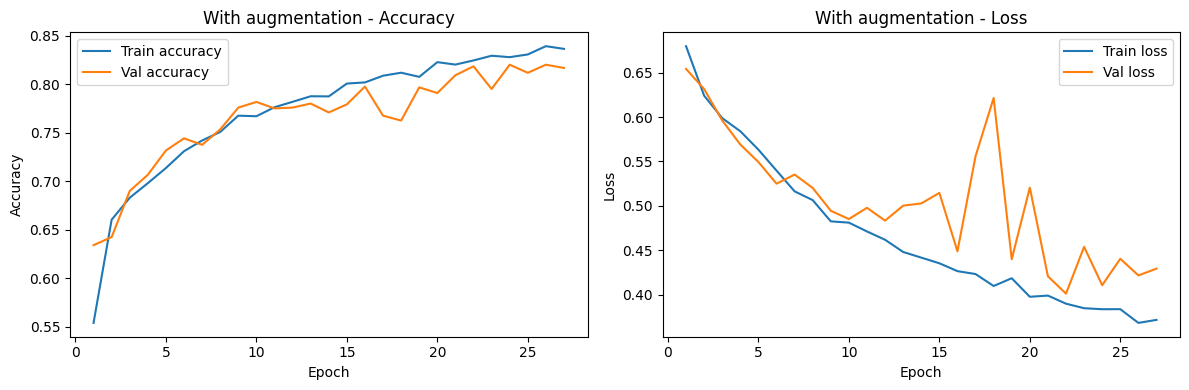

<Figure size 640x480 with 0 Axes>

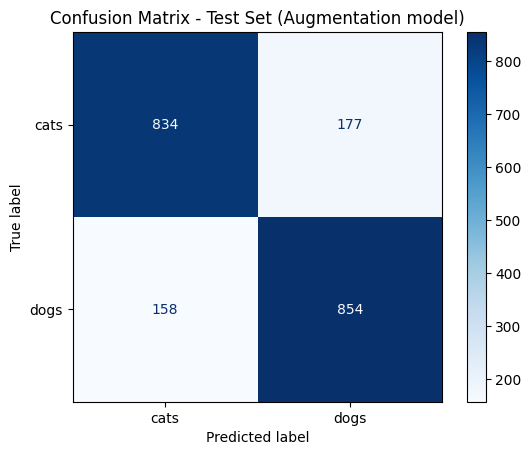

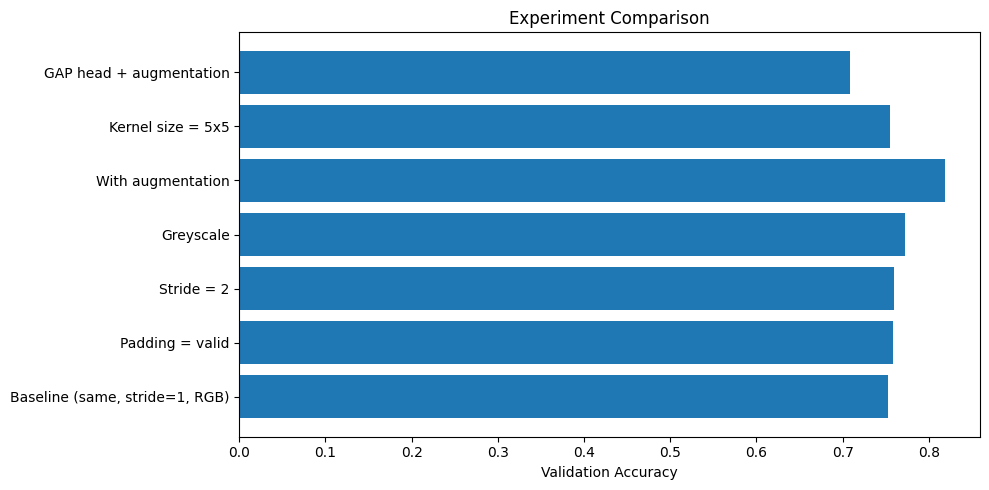

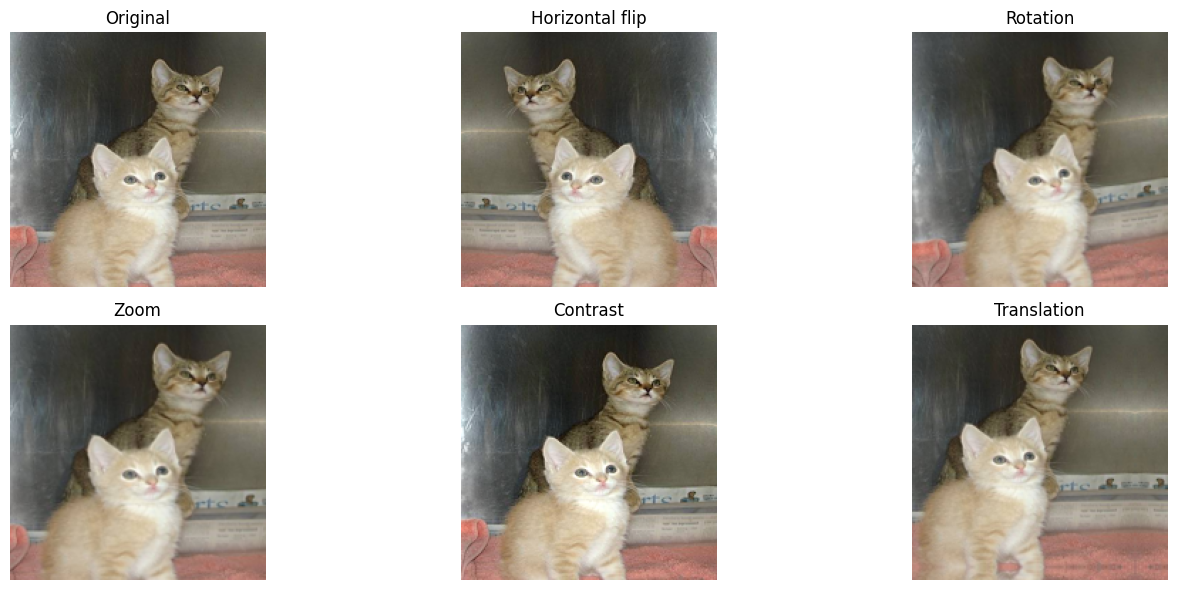

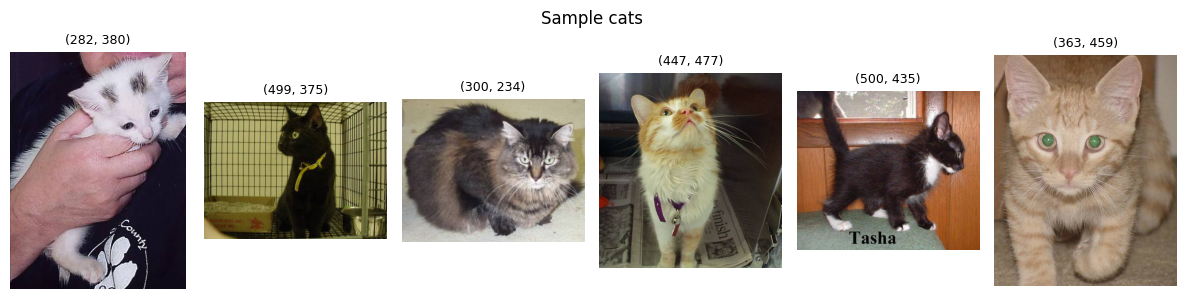

<Figure size 640x480 with 0 Axes>

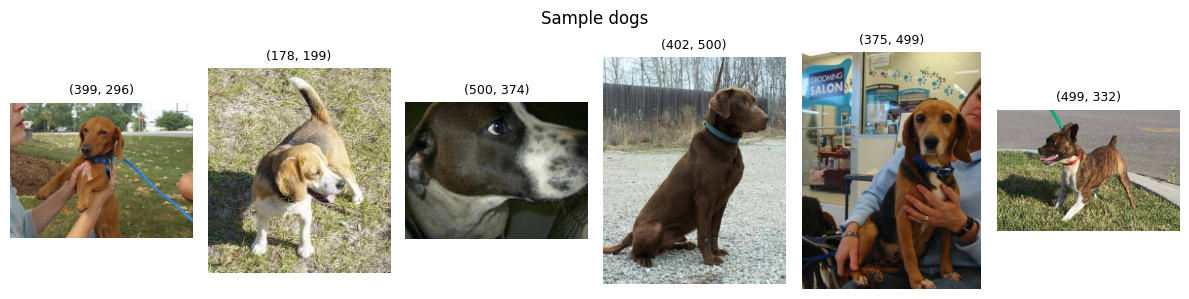

<Figure size 640x480 with 0 Axes>

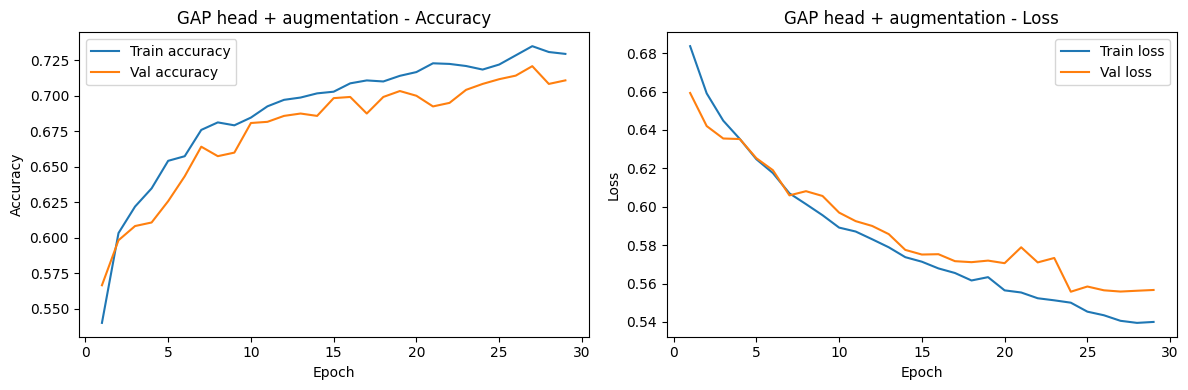

Saved plots:
sample_cats.png
augmentation_curves.png
gap_head_curves.png
baseline_curves.png
experiment_comparison.png
augmentation_examples.png
confusion_matrix.png
sample_dogs.png


<Figure size 640x480 with 0 Axes>

In [26]:
import os
os.makedirs('/content/plots', exist_ok=True)

# re-plot and save the most important ones for your report/blog

# 1. Baseline overfitting curve
plot_history(history_baseline, 'Baseline (overfitting example)')
plt.savefig('/content/plots/baseline_curves.png', dpi=150, bbox_inches='tight')

# 2. Augmentation curve (the winning fix)
plot_history(history_aug, 'With augmentation')
plt.savefig('/content/plots/augmentation_curves.png', dpi=150, bbox_inches='tight')

# 3. Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cats', 'dogs'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set (Augmentation model)')
plt.savefig('/content/plots/confusion_matrix.png', dpi=150, bbox_inches='tight')

# 4. Results comparison bar chart
plt.figure(figsize=(10,5))
df_results = pd.DataFrame(results)
plt.barh(df_results['experiment'], df_results['val_accuracy'])
plt.xlabel('Validation Accuracy')
plt.title('Experiment Comparison')
plt.tight_layout()
plt.savefig('/content/plots/experiment_comparison.png', dpi=150, bbox_inches='tight')

# 5. Data augmentation visualization (the 6-panel grid)
plt.figure(figsize=(15, 6))
for i, (name, layer) in enumerate(augmentations.items()):
    if layer is None:
        img_to_show = sample_arr[0]
    else:
        img_to_show = layer(sample_arr, training=True)[0].numpy()
    img_to_show = np.clip(img_to_show, 0, 255).astype("uint8")
    plt.subplot(2, 3, i+1)
    plt.imshow(img_to_show)
    plt.title(name)
    plt.axis('off')
plt.tight_layout()
plt.savefig('/content/plots/augmentation_examples.png', dpi=150, bbox_inches='tight')

# 6. Sample image grid
show_sample_grid('/content/data/train/cats', 'Sample cats')
plt.savefig('/content/plots/sample_cats.png', dpi=150, bbox_inches='tight')
show_sample_grid('/content/data/train/dogs', 'Sample dogs')
plt.savefig('/content/plots/sample_dogs.png', dpi=150, bbox_inches='tight')

# 7. GAP head curve (negative result)
plot_history(history_gap, 'GAP head + augmentation')
plt.savefig('/content/plots/gap_head_curves.png', dpi=150, bbox_inches='tight')

print("Saved plots:")
for f in os.listdir('/content/plots'):
    print(f)

## 22. Save results table

In [27]:
df_results = pd.DataFrame(results)
df_results.to_csv('/content/plots/results_summary.csv', index=False)
df_results

,experiment,val_accuracy,val_loss,epochs_trained,best_epoch,total_params
0,"Baseline (same, stride=1, RGB)",0.752500,0.510765,7,4,134721
1,Padding = valid,0.758333,0.502634,7,4,130241
2,Stride = 2,0.760000,0.507736,9,6,93761
3,Greyscale,0.772500,0.498112,7,4,134145
4,With augmentation,0.818333,0.401144,27,22,134721
5,Kernel size = 5x5,0.755000,0.517878,7,4,300097
6,GAP head + augmentation,0.708333,0.555743,29,24,93377


In [28]:
print(df_results.to_markdown(index=False))

| experiment                     |   val_accuracy |   val_loss |   epochs_trained |   best_epoch |   total_params |
|:-------------------------------|---------------:|-----------:|-----------------:|-------------:|---------------:|
| Baseline (same, stride=1, RGB) |       0.7525   |   0.510765 |                7 |            4 |         134721 |
| Padding = valid                |       0.758333 |   0.502634 |                7 |            4 |         130241 |
| Stride = 2                     |       0.76     |   0.507736 |                9 |            6 |          93761 |
| Greyscale                      |       0.7725   |   0.498112 |                7 |            4 |         134145 |
| With augmentation              |       0.818333 |   0.401144 |               27 |           22 |         134721 |
| Kernel size = 5x5              |       0.755    |   0.517878 |                7 |            4 |         300097 |
| GAP head + augmentation        |       0.708333 |   0.555743 |        